# Notebook 01 — SimpleMLP 784→8→4→2 on MNIST Even/Odd (digits 0,1,3,4)

**Architecture:** SimpleMLP with hidden dims [8, 4], trained on MNIST digits 0, 1, 3, 4 with even/odd binary labels.

## Structure
1. **Setup** — imports, config, device
2. **Models** — load or train 5 seeds into `data/models/`
3. **Factorization & Inspection** — BFT on seed 0: factor panels, pixel receptive fields, scaffold graphs
4. **Ablation** — 5-seed comparative sweep + causal circuit ablation
5. **New Stimuli via NNLS** — round-trip, ID train, near-OOD (excluded digits), far-OOD (synthetic)

## §0 — Imports & Config

In [1]:
%matplotlib inline
import sys, os, pickle, copy
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from scipy.integrate import trapezoid
from scipy.stats import wilcoxon
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances, paired_cosine_distances
from sklearn.decomposition import PCA

from src import (
    SimpleMLP,
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    bft, evaluate,
    build_scaffold_edges, scaffold_loading_from_edges, plot_scaffold_graph,
    assign_factors_to_classes, path_from_child, extract_importance_scores,
    magnitude_scores, act_magnitude_scores, taylor_scores,
    ablate_model, run_ablation_sweep, per_class_accuracy,
    extract_tree_nodes, extract_factor_tree_nodes,
    extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree, compute_factor_activations,
    nodes_at_layer, plot_factor_tree, top_stimuli_factor_activations,
    save_experiment,
)
from src.training import train_epoch, label_transform_even_odd
from src.data_utils import get_mnist_loaders

matplotlib.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)

MODEL_ROOT = os.path.join(_repo_dir, 'data', 'models')
CACHE_ROOT = os.path.join(_repo_dir, 'data', 'cache', 'nb01_mlp84')
FIG_DIR    = os.path.join(_repo_dir, 'figs', '01_mlp_8_4_0134')
for d in [MODEL_ROOT, CACHE_ROOT, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Experiment config ──────────────────────────────────────────────────────────
EXP_BASE      = 'mnist_even_odd_mlp_8_4_0134'
N_SEEDS       = 5
N_EPOCHS      = 30

# ── BFT config ────────────────────────────────────────────────────────────────
N_BRANCHES         = [8, 2, 2]
K_MAX_PER_LAYER    = [12, 12, 12]
STIMULUS_THRESHOLD = 0.7
N_VIZ              = 4

# ── Ablation config ───────────────────────────────────────────────────────────
N_CLASSES        = 2
CLASS_NAMES      = {0: 'even', 1: 'odd'}
ABLATION_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_RANDOM_REPEATS = 10
PERCENTILES      = [50, 75, 90, 95, 99]
N_PER_CLASS      = 200

# ── NNLS / OOD ────────────────────────────────────────────────────────────────
TOP_N_FACTOR  = 50
IMAGE_SIDE    = 28
N_FAR_OOD     = 300

# ── Caching ───────────────────────────────────────────────────────────────────
USE_CACHED_BFT  = True
USE_CACHED_ABL  = True

print(f'MODEL_ROOT: {MODEL_ROOT}')
print(f'CACHE_ROOT: {CACHE_ROOT}')
print(f'FIG_DIR:    {FIG_DIR}')

MODEL_ROOT: /Users/johannesbertram/repos/Weight_Interpretability/data/models
CACHE_ROOT: /Users/johannesbertram/repos/Weight_Interpretability/data/cache/nb01_mlp84
FIG_DIR:    /Users/johannesbertram/repos/Weight_Interpretability/figs/01_mlp_8_4_0134


## §1 — Models: load or train 5 seeds

In [3]:
BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 32,
                       'digit_filter': [0, 1, 3, 4]},
    'label_transform': 'even_odd',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

models_by_seed = {}

for seed in range(N_SEEDS):
    exp_dir = os.path.join(MODEL_ROOT, f'{EXP_BASE}_seed{seed}')
    if os.path.exists(os.path.join(exp_dir, 'weights.pt')):
        m, cfg = load_experiment(exp_dir, DEVICE)
        models_by_seed[seed] = (m, cfg)
        print(f'Seed {seed}: loaded from {exp_dir}')
    else:
        print(f'Seed {seed}: training from scratch...')
        torch.manual_seed(seed)
        np.random.seed(seed)
        m = SimpleMLP(**BASE_CONFIG['arch_kwargs']).to(DEVICE)
        cfg = dict(BASE_CONFIG, description=f'{EXP_BASE} seed {seed}')

        train_loader, test_loader = get_mnist_loaders(
            batch_size=32, root='../data/', digit_filter=[0,1,3,4])
        label_transform = label_transform_even_odd
        optimizer = torch.optim.Adam(m.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        for ep in range(N_EPOCHS):
            train_epoch(m, train_loader, optimizer, criterion, DEVICE, label_transform)
        _, acc = evaluate(m, test_loader, criterion, DEVICE, label_transform)
        print(f'  Test acc: {acc:.4f}')

        cfg['description'] = f'{EXP_BASE} seed {seed}'
        save_experiment(m, cfg, exp_dir)
        models_by_seed[seed] = (m, cfg)
        print(f'  Saved to {exp_dir}')

# Canonical model is seed 0
model, config = models_by_seed[0]
train_loader, test_loader = get_loaders_from_config(config)
label_transform = get_transform(config['label_transform'])
_, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE, label_transform)

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
print(f'\nSeed-0 test accuracy: {test_acc:.4f}')
print(f'Architecture (per-layer neurons): {LAYER_SIZES}')

Seed 0: loaded from /Users/johannesbertram/repos/Weight_Interpretability/data/models/mnist_even_odd_mlp_8_4_0134_seed0
Seed 1: training from scratch...
  Test acc: 0.9951
  Saved to /Users/johannesbertram/repos/Weight_Interpretability/data/models/mnist_even_odd_mlp_8_4_0134_seed1
Seed 2: training from scratch...
  Test acc: 0.9934
  Saved to /Users/johannesbertram/repos/Weight_Interpretability/data/models/mnist_even_odd_mlp_8_4_0134_seed2
Seed 3: training from scratch...
  Test acc: 0.9929
  Saved to /Users/johannesbertram/repos/Weight_Interpretability/data/models/mnist_even_odd_mlp_8_4_0134_seed3
Seed 4: training from scratch...
  Test acc: 0.9937
  Saved to /Users/johannesbertram/repos/Weight_Interpretability/data/models/mnist_even_odd_mlp_8_4_0134_seed4

Seed-0 test accuracy: 0.9929
Architecture (per-layer neurons): [8, 4, 2]


## §2 — Factorization & Inspection (seed 0)

### 2a — Collect layer data and run BFT

In [4]:
data = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=DEVICE,
)
all_images   = data['images']        # (N, 1, 28, 28)
all_targets  = data['targets']       # (N,) even/odd labels
all_digits   = data['digits']        # (N,) original digit
layer_inputs = data['layer_inputs']  # list[(N, n_in)], forward order
n_samples    = len(all_images)
flat_imgs    = all_images.reshape(n_samples, -1)

print(f'Samples: {n_samples}')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')
for i, li in enumerate(layer_inputs):
    print(f'  L{i+1} inputs: {li.shape}')

Samples: 4078
Class distribution: {np.int64(0): np.int64(1946), np.int64(1): np.int64(2132)}
  L1 inputs: (4078, 784)
  L2 inputs: (4078, 8)
  L3 inputs: (4078, 4)


In [5]:
_bft_cache = os.path.join(CACHE_ROOT, 'bft_seed0.pkl')

if USE_CACHED_BFT and os.path.exists(_bft_cache):
    with open(_bft_cache, 'rb') as f:
        tree_root = pickle.load(f)
    print('Loaded BFT tree from cache')
else:
    tree_root = bft(
        model, layer_inputs,
        k_max=K_MAX_PER_LAYER,
        n_branches=N_BRANCHES,
        stimulus_threshold=STIMULUS_THRESHOLD,
        weighting='img_selectivity',
        verbose=1,
        n_jobs=3,
    )
    with open(_bft_cache, 'wb') as f:
        pickle.dump(tree_root, f)
    print('BFT done, cached.')

def get_nodes_by_depth(root):
    from collections import deque
    by_depth = {}
    queue = deque([(root, 0)])
    while queue:
        node, d = queue.popleft()
        by_depth.setdefault(d, []).append(node)
        for child in node['children']:
            queue.append((child, d+1))
    return by_depth

def get_all_paths(root):
    if not root['children']: return [[root]]
    return [[root] + p for child in root['children'] for p in get_all_paths(child)]

nodes_by_depth = get_nodes_by_depth(tree_root)
all_paths      = get_all_paths(tree_root)
print(f'Tree: {len(nodes_by_depth)} depths, {sum(len(v) for v in nodes_by_depth.values())} nodes, {len(all_paths)} paths')

[BFT] Layer 3/3 '2' (fc)  path=[]
[BFT L3 '2' (fc)]   K=9  t=0.038s
[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT L2 '1' (fc)]   K=1  t=0.037s
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT L1 '0' (fc)]   K=12  t=0.785s
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT L2 '1' (fc)]   K=1  t=0.017s
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2147: RuntimeWarning: invalid value encountered in scalar divide
  H_diff = linalg.norm(H - H_buffer) / linalg.norm(H)


[BFT L1 '0' (fc)]   K=11  t=0.506s
BFT done, cached.
Tree: 3 depths, 5 nodes, 2 paths


### 2b — Per-layer factor visualizations

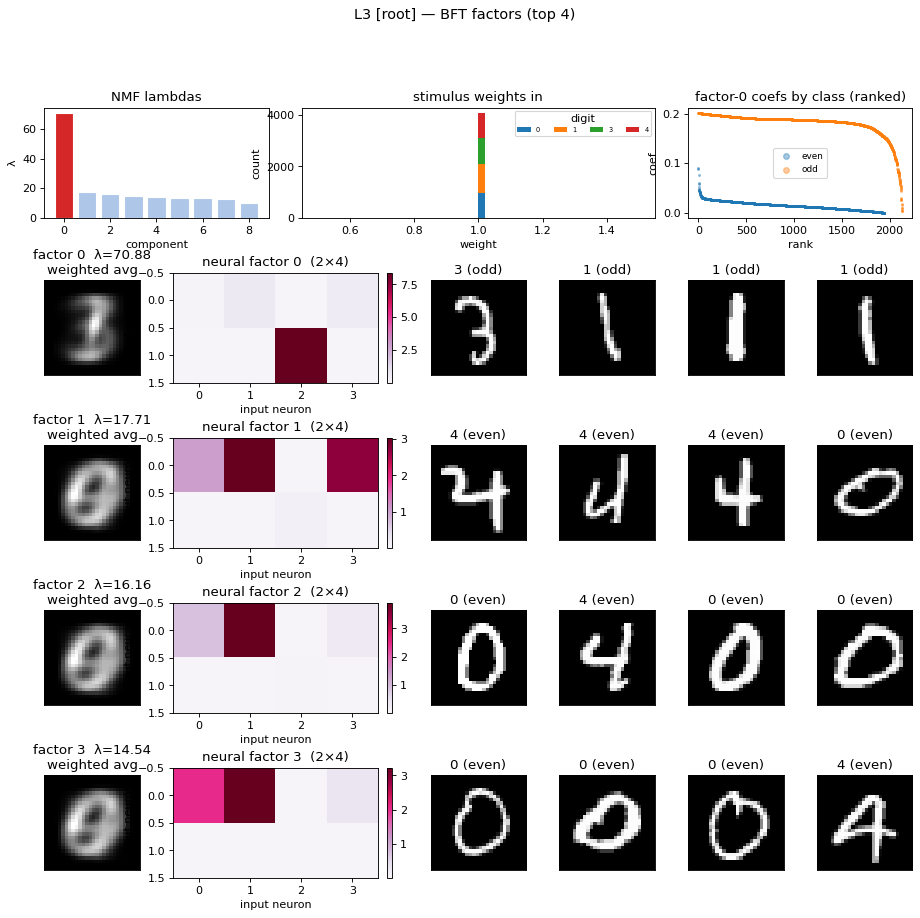

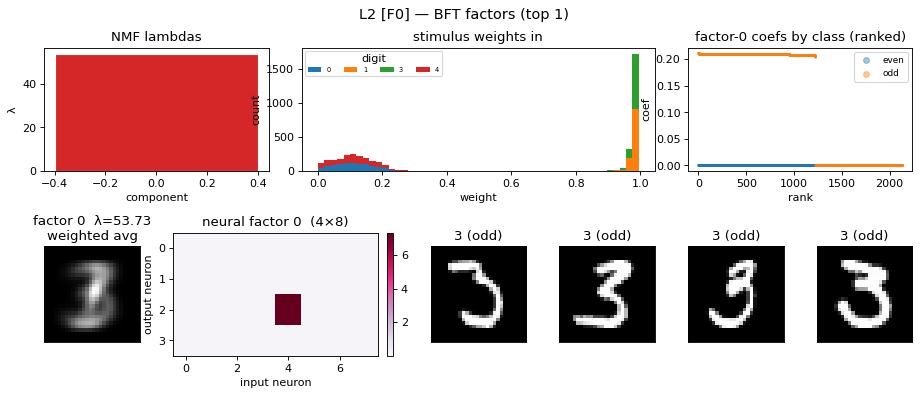

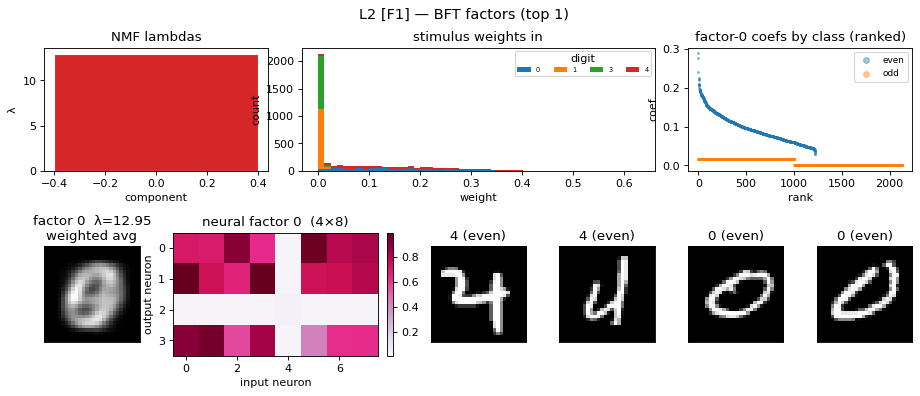

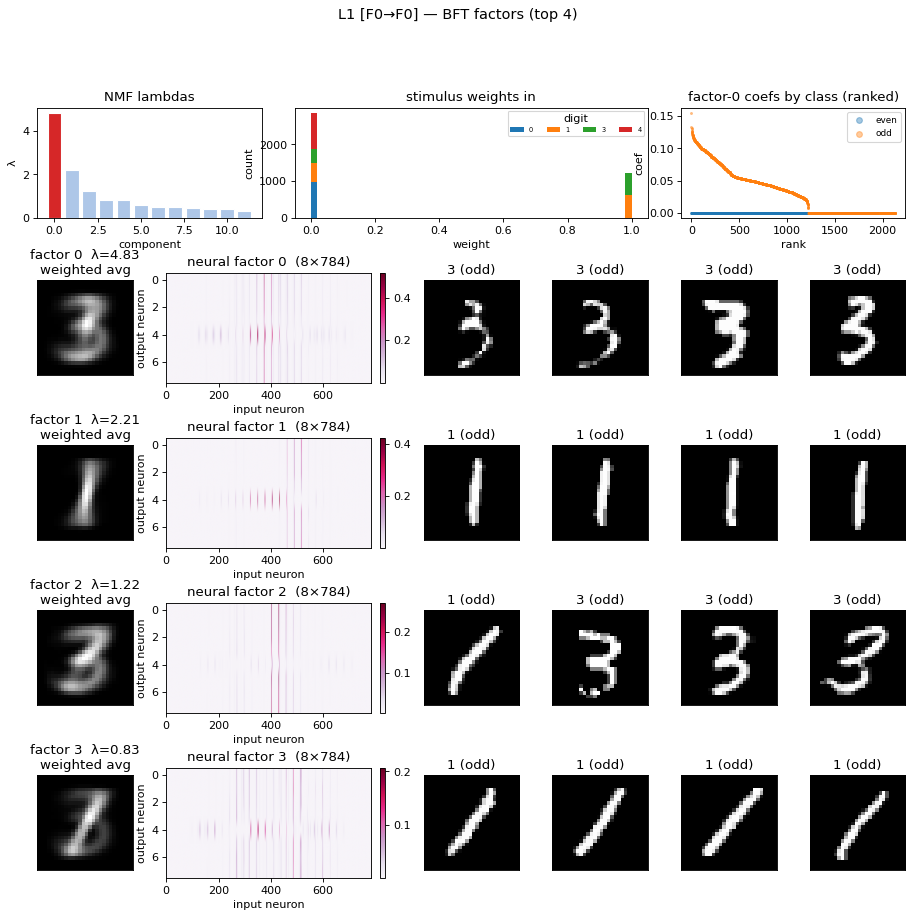

In [6]:
cmap_tab = matplotlib.colormaps['tab10']
_inline_shown = 0
_MAX_INLINE   = 4

for depth in sorted(nodes_by_depth.keys()):
    for r in nodes_by_depth[depth]:
        l_idx  = r['layer_idx']
        n_out, n_in = r['W'].shape
        img_f  = r['img_factors']     # (N, K)
        neu_f  = r['neural_factors']  # (n_out*n_in, K)
        lams   = r['lambdas']
        n_show = min(N_VIZ, len(lams))
        path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'

        fig = plt.figure(figsize=(14, 2.5 * (n_show + 1)))
        fig.suptitle(f'L{l_idx+1} [{path_label}] — BFT factors (top {n_show})', fontsize=13)
        gs  = gridspec.GridSpec(n_show + 1, 7, figure=fig, hspace=0.5, wspace=0.35)

        # Row 0: overview
        ax_lam = fig.add_subplot(gs[0, 0:2])
        ax_lam.bar(range(len(lams)), lams,
                   color=['#d62728'] + ['#aec7e8']*(len(lams)-1), edgecolor='white')
        ax_lam.set(xlabel='component', ylabel='λ', title='NMF lambdas')

        ax_hist = fig.add_subplot(gs[0, 2:5])
        sw = r['stimulus_weights_in']
        digits_unique = sorted(np.unique(all_digits))
        ax_hist.hist([sw[all_digits==d] for d in digits_unique], bins=50, stacked=True,
                     color=[cmap_tab(i) for i in range(len(digits_unique))],
                     label=[str(d) for d in digits_unique], edgecolor='none')
        ax_hist.legend(fontsize=6, ncol=5, title='digit')
        ax_hist.set(title='stimulus weights in', xlabel='weight', ylabel='count')

        ax_cls = fig.add_subplot(gs[0, 5:7])
        for ci, cl in enumerate(sorted(np.unique(all_targets))):
            mask = all_targets == cl
            ax_cls.scatter(np.arange(mask.sum()), np.sort(img_f[mask, 0])[::-1],
                           s=3, alpha=0.4, color=cmap_tab(ci), label=CLASS_NAMES.get(cl, str(cl)))
        ax_cls.set(title='factor-0 coefs by class (ranked)', xlabel='rank', ylabel='coef')
        ax_cls.legend(markerscale=3, fontsize=8)

        # Factor rows
        for fi in range(n_show):
            coefs_k    = img_f[:, fi]
            per_neuron = neu_f[:, fi].reshape(n_out, n_in)

            ax_wav = fig.add_subplot(gs[fi+1, 0])
            w_avg  = (coefs_k[:, None] * flat_imgs).sum(0) / (coefs_k.sum() + 1e-12)
            ax_wav.imshow(w_avg.reshape(IMAGE_SIDE, IMAGE_SIDE), cmap='gray')
            ax_wav.set(title=f'factor {fi}  λ={lams[fi]:.2f}\nweighted avg', xticks=[], yticks=[])

            ax_nf = fig.add_subplot(gs[fi+1, 1:3])
            im = ax_nf.imshow(per_neuron, aspect='auto', cmap='PuRd')
            plt.colorbar(im, ax=ax_nf, fraction=0.046, pad=0.04)
            ax_nf.set(title=f'neural factor {fi}  ({n_out}×{n_in})',
                      xlabel='input neuron', ylabel='output neuron')

            top_idx = np.argsort(coefs_k)[::-1][:4]
            for col_i, s_idx in enumerate(top_idx):
                ax_img = fig.add_subplot(gs[fi+1, 3+col_i])
                ax_img.imshow(all_images[s_idx].squeeze(), cmap='gray')
                d = all_digits[s_idx]; cl = all_targets[s_idx]
                ax_img.set(title=f'{d} ({CLASS_NAMES.get(cl, cl)})', xticks=[], yticks=[])

        _pl = path_label.replace('→', '-')
        fig.savefig(os.path.join(FIG_DIR, f'L{l_idx+1}_{_pl}_factors.pdf'), bbox_inches='tight')
        if _inline_shown < _MAX_INLINE:
            plt.show(); _inline_shown += 1
        else:
            plt.close(fig)

### 2c — Layer-1 Pixel Receptive Fields

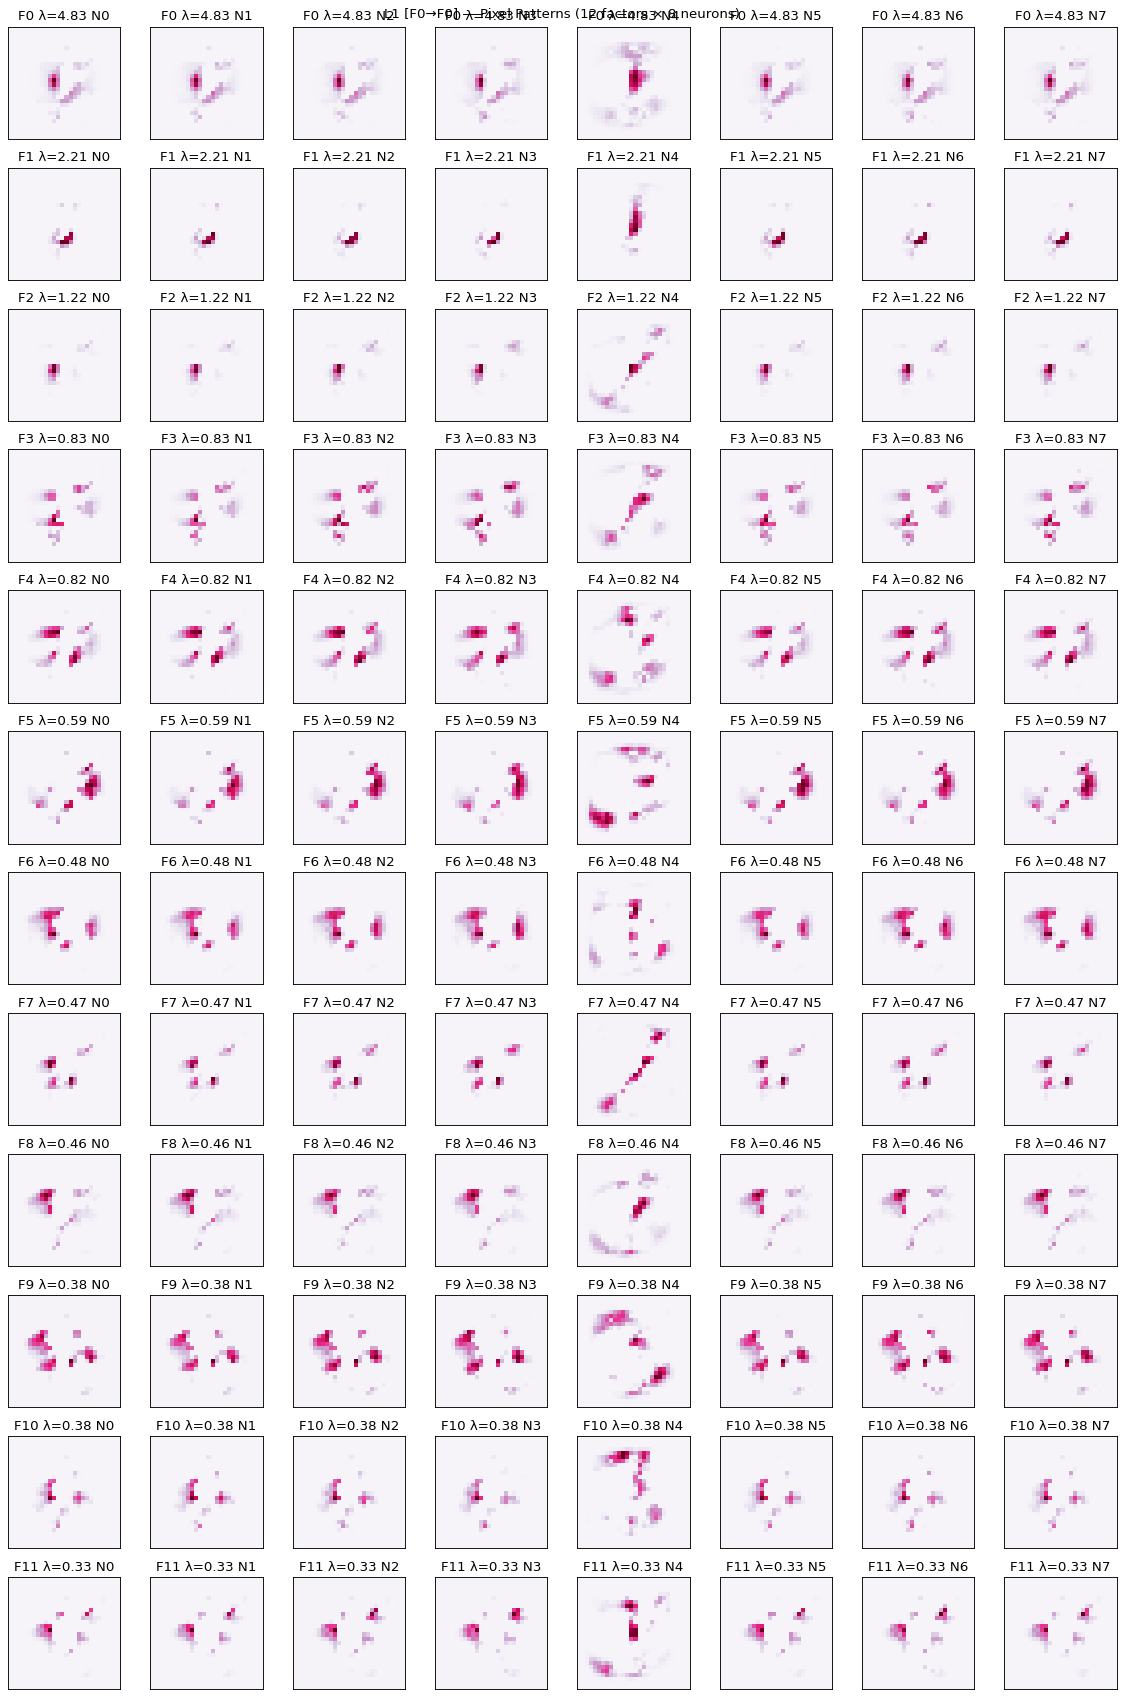

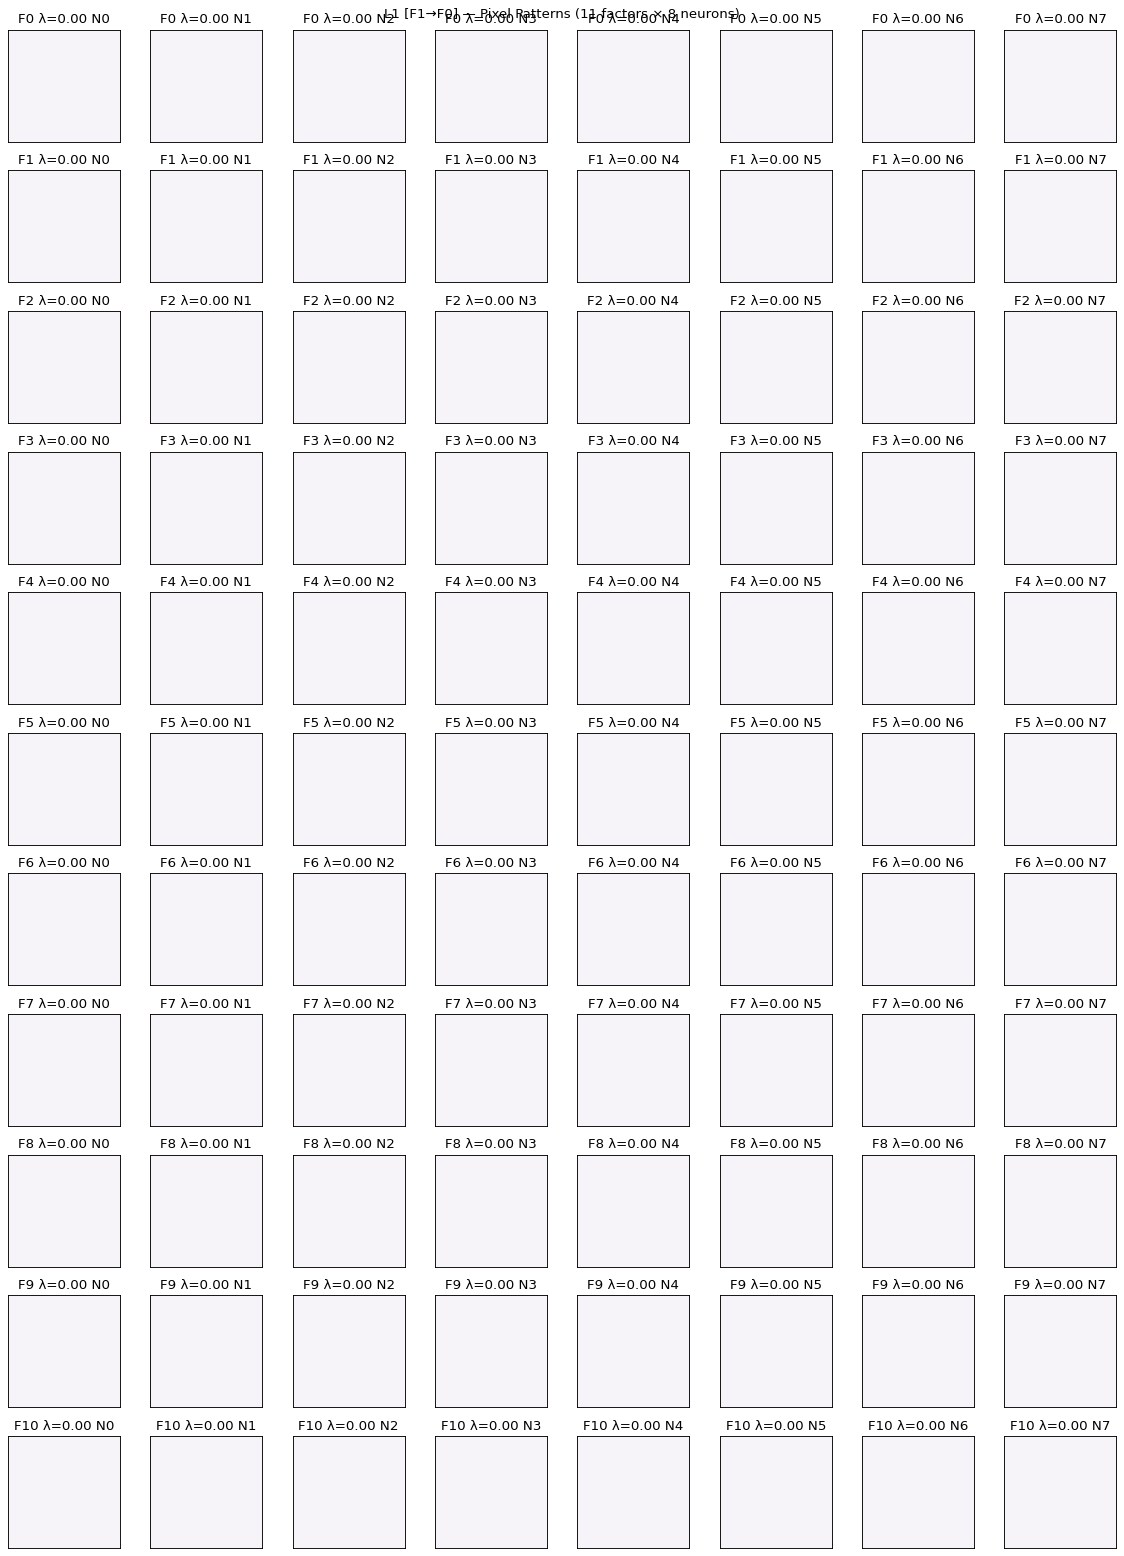

In [7]:
max_depth = max(nodes_by_depth.keys())

for r in nodes_by_depth[max_depth]:
    n_out_L1 = r['W'].shape[0]
    neu_f    = r['neural_factors']
    lams     = r['lambdas']
    K_actual = len(lams)
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'

    fig, axes = plt.subplots(K_actual, n_out_L1, figsize=(n_out_L1*1.8, K_actual*1.8), squeeze=False)
    fig.suptitle(f'L1 [{path_label}] — Pixel Patterns ({K_actual} factors × {n_out_L1} neurons)', fontsize=12)

    for fi in range(K_actual):
        patterns = neu_f[:, fi].reshape(n_out_L1, IMAGE_SIDE, IMAGE_SIDE)
        for ni in range(n_out_L1):
            ax = axes[fi, ni]
            p  = patterns[ni]
            pmax = p.max() or 1
            ax.imshow(np.log1p(p/pmax*(np.e-1)), cmap='PuRd', vmin=0, vmax=1)
            ax.set(title=f'F{fi} λ={lams[fi]:.2f} N{ni}', xticks=[], yticks=[])

    plt.tight_layout()
    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_DIR, f'L1_{_pl}_pixel_rf.pdf'), bbox_inches='tight')
    plt.show()

### 2d — Full Network Scaffold Graphs

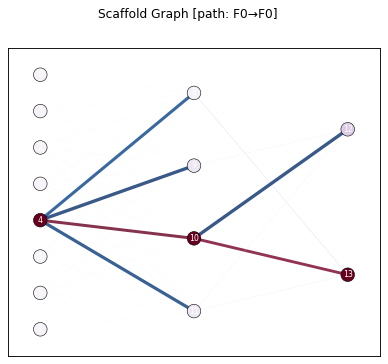

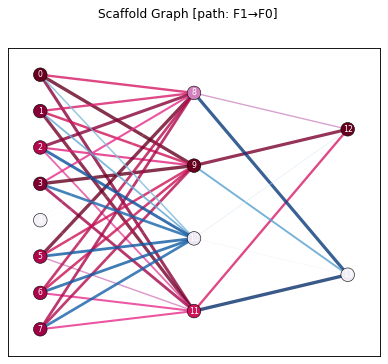

In [8]:
for path_nodes in all_paths:
    layer_results = list(reversed(path_nodes))  # L1-first order

    edge_matrices, neg_edge_matrices = build_scaffold_edges(
        layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
    )
    loading = scaffold_loading_from_edges(edge_matrices)

    path_label = 'F' + '→F'.join(str(f) for f in path_nodes[-1]['path'])

    fig = plot_scaffold_graph(loading, edge_matrices, LAYER_SIZES,
                              neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(f'Scaffold Graph [path: {path_label}]', fontsize=11)

    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{_pl}.pdf'), bbox_inches='tight')
    plt.show()

## §3 — Ablation (all 5 seeds)

### 3a — Comparative ablation sweep

In [9]:
METHODS = ['algo_top', 'algo_bottom', 'magnitude', 'act_magnitude', 'taylor', 'random']
METHOD_STYLES = {
    'algo_top':      dict(color='red',       lw=2.0, ls='-',  label='algo (top)'),
    'algo_bottom':   dict(color='orange',    lw=1.5, ls='--', label='algo (bottom)'),
    'magnitude':     dict(color='gray',      lw=1.5, ls='-',  label='magnitude'),
    'act_magnitude': dict(color='steelblue', lw=1.5, ls='--', label='act × magnitude'),
    'taylor':        dict(color='green',     lw=1.5, ls='-',  label='Taylor'),
    'random':        dict(color='black',     lw=1.0, ls=':',  label='random'),
}

# K-trace for ablation (smaller for speed)
K_TRACE = [12, 12, 12]
N_BRANCHES_ABL = [1, 1, N_CLASSES]   # one branch per class at output
STIM_THRESH_ABL = 0.1

os.makedirs(os.path.join(CACHE_ROOT, 'ablation'), exist_ok=True)

In [10]:
# Load the full test set for evaluation
mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
# Filter to training digits only
digit_filter = config['dataset_kwargs']['digit_filter']
mask = np.isin(np.array(mnist_test_full.targets), digit_filter)
test_ds_filtered = Subset(mnist_test_full, np.where(mask)[0])
test_loader_abl  = DataLoader(test_ds_filtered, batch_size=256, shuffle=False)

all_results = []

for seed_idx in range(N_SEEDS):
    cache_path = os.path.join(CACHE_ROOT, 'ablation', f'seed{seed_idx}.pkl')

    if USE_CACHED_ABL and os.path.exists(cache_path):
        print(f'[seed {seed_idx}] loading from cache')
        with open(cache_path, 'rb') as f:
            all_results.append(pickle.load(f))
        continue

    print(f'\n=== seed {seed_idx} ===')
    m_s, cfg_s = models_by_seed[seed_idx]

    layer_data = collect_layer_inputs(
        m_s, test_ds_filtered, label_transform=label_transform_even_odd,
        n_per_class=None, device=DEVICE,
    )
    li_s    = layer_data['layer_inputs']
    tgt_s   = layer_data['targets']

    root = bft(m_s, li_s, k_max=K_TRACE, n_branches=N_BRANCHES_ABL,
               stimulus_threshold=STIM_THRESH_ABL, n_jobs=3)
    class_to_child = assign_factors_to_classes(root, tgt_s, N_CLASSES)

    algo_scores = {}
    for d in range(N_CLASSES):
        path = path_from_child(root, class_to_child[d])
        algo_scores[d] = extract_importance_scores(path)

    mag_sc  = magnitude_scores(m_s)
    amag_sc = act_magnitude_scores(m_s, li_s)

    seed_results = {m: {} for m in METHODS}

    for d in range(N_CLASSES):
        print(f'  class {d} ({CLASS_NAMES[d]})', end=' ', flush=True)
        tay_sc = taylor_scores(m_s, test_loader_abl, label_transform_even_odd, DEVICE, d)
        score_map = {
            'algo_top':      algo_scores[d],
            'algo_bottom':   algo_scores[d],
            'magnitude':     mag_sc,
            'act_magnitude': amag_sc,
            'taylor':        tay_sc,
            'random':        mag_sc,
        }
        for method in METHODS:
            seed_results[method][d] = run_ablation_sweep(
                m_s, score_map[method], ABLATION_FRACS,
                test_loader_abl, label_transform_even_odd, DEVICE,
                method=method, n_random_repeats=N_RANDOM_REPEATS,
            )
        print('done')

    with open(cache_path, 'wb') as f:
        pickle.dump(seed_results, f)
    all_results.append(seed_results)

valid = [r for r in all_results if r is not None]
print(f'\nValid seeds: {len(valid)}')

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_50183/2019206130.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask = np.isin(np.array(mnist_test_full.targets), digit_filter)



=== seed 0 ===


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 0 (even) done
  class 1 (odd) done

=== seed 1 ===


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


...

done
  class 1 (odd) done

=== seed 4 ===


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 0 (even) 

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


done
  class 1 (odd) done

Valid seeds: 5


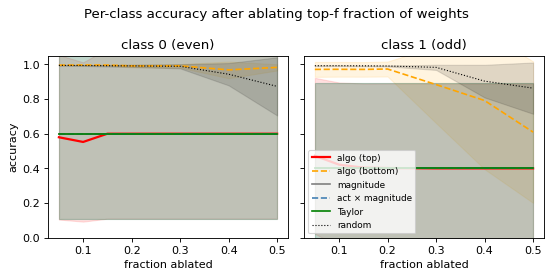

method          AUC_target  AUC_others
algo_top          0.2252      0.2519
algo_bottom       0.4181      0.4210
magnitude         0.2250      0.2250
act_magnitude     0.2250      0.2250
taylor            0.2250      0.2250
random            0.4326      0.4272


In [11]:
# Per-class accuracy vs ablation fraction
fig, axes = plt.subplots(1, N_CLASSES, figsize=(7, 3.5), sharey=True)
for d in range(N_CLASSES):
    ax = axes[d]
    for method in METHODS:
        accs = np.array([[r[method][d][f][d] for f in ABLATION_FRACS] for r in valid])
        mu, std = accs.mean(0), accs.std(0)
        st = METHOD_STYLES[method]
        ax.plot(ABLATION_FRACS, mu, color=st['color'], lw=st['lw'], ls=st['ls'], label=st['label'])
        ax.fill_between(ABLATION_FRACS, mu-std, mu+std, color=st['color'], alpha=0.12)
    ax.set_title(f'class {d} ({CLASS_NAMES[d]})')
    ax.set_xlabel('fraction ablated')
    if d == 0: ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1.05)
axes[-1].legend(loc='lower left', fontsize=8)
fig.suptitle('Per-class accuracy after ablating top-f fraction of weights', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'abl_per_class_accuracy.pdf'), bbox_inches='tight')
plt.show()

# Specificity summary
fracs = np.array(ABLATION_FRACS)
rows = []
for method in METHODS:
    auc_t_all, auc_o_all = [], []
    for r in valid:
        for d in range(N_CLASSES):
            at = trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
            ao = np.mean([trapezoid([r[method][d][f][c] for f in ABLATION_FRACS], fracs)
                          for c in range(N_CLASSES) if c != d])
            auc_t_all.append(at); auc_o_all.append(ao)
    rows.append((method, np.mean(auc_t_all), np.mean(auc_o_all)))

print('method          AUC_target  AUC_others')
for method, mt, mo in rows:
    print(f'{method:<16}  {mt:.4f}      {mo:.4f}')

### 3b — Causal circuit ablation (class-specific circuits)

Seed 0: computing causal ablation...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 0: target drop@90 = 0.992


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 1: target drop@90 = -0.006
Seed 1: computing causal ablation...


...

  class 1: target drop@90 = 0.991
Seed 4: computing causal ablation...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 0: target drop@90 = -0.002


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


  class 1: target drop@90 = 0.993


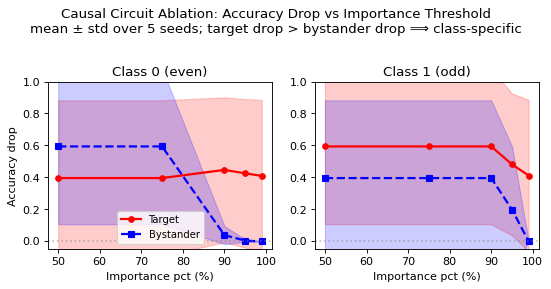


Causal ablation @ pct=90 (n=10 pairs):
  Target drop:    0.519 ± 0.479
  Bystander drop: 0.215 ± 0.391
  Wilcoxon p = 0.2080


In [12]:
def circuit_keys_at_pct(scores, pct):
    vals = np.array(list(scores.values()))
    thr  = np.percentile(vals, pct)
    return [k for k, v in scores.items() if v >= thr]

causal = {}
K_TRACE_S3 = [12, 12, 12]

for s in range(N_SEEDS):
    _p = os.path.join(CACHE_ROOT, 'ablation', f'causal_seed{s}.pkl')
    if USE_CACHED_ABL and os.path.exists(_p):
        with open(_p, 'rb') as f:
            causal[s] = pickle.load(f)
        print(f'Seed {s}: loaded causal from cache')
        continue

    print(f'Seed {s}: computing causal ablation...')
    m_s, _ = models_by_seed[s]
    data_s = collect_layer_inputs(
        m_s, test_ds_filtered, label_transform=label_transform_even_odd,
        n_per_class=N_PER_CLASS, device=DEVICE,
    )
    li_s  = data_s['layer_inputs']
    tgt_s = data_s['targets']
    base_accs = per_class_accuracy(m_s, test_loader_abl, label_transform_even_odd, DEVICE)

    causal[s] = {}
    for d in range(N_CLASSES):
        mask_d = tgt_s == d
        li_d   = [x[mask_d] for x in li_s]
        _root_d = bft(m_s, li_d, k_max=K_TRACE_S3, n_branches=1,
                      stimulus_threshold=STIM_THRESH_ABL, n_jobs=3)
        trace_d = [_root_d]
        _nd = _root_d
        while _nd['children']:
            _nd = _nd['children'][0]; trace_d.append(_nd)
        scores_d = extract_importance_scores(trace_d)

        all_accs = {}
        for pct in PERCENTILES:
            keys      = circuit_keys_at_pct(scores_d, pct)
            abl_model = ablate_model(m_s, keys)
            all_accs[pct] = per_class_accuracy(abl_model, test_loader_abl, label_transform_even_odd, DEVICE)

        causal[s][d] = {'baseline_accs': base_accs, 'all_class_accs': all_accs}
        print(f'  class {d}: target drop@90 = {base_accs[d] - all_accs[90][d]:.3f}')

    with open(_p, 'wb') as f:
        pickle.dump(causal[s], f)

# Plot causal curves
fig, axes = plt.subplots(1, N_CLASSES, figsize=(7, 3.5))
for d in range(N_CLASSES):
    ax = axes[d]
    tgt_mean, bys_mean, tgt_std, bys_std = [], [], [], []
    for pct in PERCENTILES:
        t_vals, b_vals = [], []
        for s in range(N_SEEDS):
            base = causal[s][d]['baseline_accs']
            abl  = causal[s][d]['all_class_accs'][pct]
            t_vals.append(base[d] - abl[d])
            b_vals.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))
        tgt_mean.append(np.mean(t_vals)); tgt_std.append(np.std(t_vals))
        bys_mean.append(np.mean(b_vals)); bys_std.append(np.std(b_vals))

    ax.plot(PERCENTILES, tgt_mean, 'r-o', lw=2, ms=5, label='Target')
    ax.fill_between(PERCENTILES, np.array(tgt_mean)-np.array(tgt_std),
                    np.array(tgt_mean)+np.array(tgt_std), alpha=0.2, color='r')
    ax.plot(PERCENTILES, bys_mean, 'b--s', lw=2, ms=5, label='Bystander')
    ax.fill_between(PERCENTILES, np.array(bys_mean)-np.array(bys_std),
                    np.array(bys_mean)+np.array(bys_std), alpha=0.2, color='b')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_title(f'Class {d} ({CLASS_NAMES[d]})', fontsize=12)
    ax.set_xlabel('Importance pct (%)')
    if d == 0: ax.set_ylabel('Accuracy drop')
    ax.set_ylim(-0.05, 1.0)
    if d == 0: ax.legend(fontsize=9)

plt.suptitle('Causal Circuit Ablation: Accuracy Drop vs Importance Threshold\n'
             'mean ± std over 5 seeds; target drop > bystander drop ⟹ class-specific', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'causal_ablation.pdf'), bbox_inches='tight')
plt.show()

# Statistical test at pct=90
tgt_90, bys_90 = [], []
for s in range(N_SEEDS):
    for d in range(N_CLASSES):
        base = causal[s][d]['baseline_accs']
        abl  = causal[s][d]['all_class_accs'][90]
        tgt_90.append(base[d] - abl[d])
        bys_90.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))
tgt_90 = np.array(tgt_90); bys_90 = np.array(bys_90)
stat, pval = wilcoxon(tgt_90 - bys_90, alternative='greater')
print(f'\nCausal ablation @ pct=90 (n={len(tgt_90)} pairs):')
print(f'  Target drop:    {tgt_90.mean():.3f} ± {tgt_90.std():.3f}')
print(f'  Bystander drop: {bys_90.mean():.3f} ± {bys_90.std():.3f}')
print(f'  Wilcoxon p = {pval:.4f}')

## §4 — New Stimuli via NNLS

### 4a — BFT factor tree for NNLS (seed 0)

In [13]:
_nnls_bft_cache = os.path.join(CACHE_ROOT, 'bft_nnls_seed0.pkl')

if USE_CACHED_BFT and os.path.exists(_nnls_bft_cache):
    with open(_nnls_bft_cache, 'rb') as f:
        nnls_root = pickle.load(f)
    print('Loaded NNLS BFT from cache')
else:
    nnls_root = bft(
        model, layer_inputs,
        k_max=[10, 1, 2], n_branches=[8, 2, 2],
        stimulus_threshold=0, weighting='img_selectivity', n_jobs=3,
    )
    with open(_nnls_bft_cache, 'wb') as f:
        pickle.dump(nnls_root, f)
    print('NNLS BFT done, cached.')

nnls_tree_nodes   = extract_tree_nodes(nnls_root)
nnls_factor_nodes = extract_factor_tree_nodes(nnls_root)

# Round-trip test
from sklearn.metrics.pairwise import paired_cosine_distances as _pcd
projected_test_rt = project_stimuli_onto_tree(nnls_root, layer_inputs)
F_orig = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))
F_rt   = extract_fingerprint_matrix(projected_test_rt, np.arange(n_samples))
rt_sims = 1.0 - _pcd(F_orig, F_rt)
print(f'Round-trip cosine sim: mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NNLS BFT done, cached.
Round-trip cosine sim: mean=0.9879  std=0.0139  min=0.9267


### 4b — Factor fingerprints & similarity (test set)

Fingerprint matrix: (4078, 24)


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


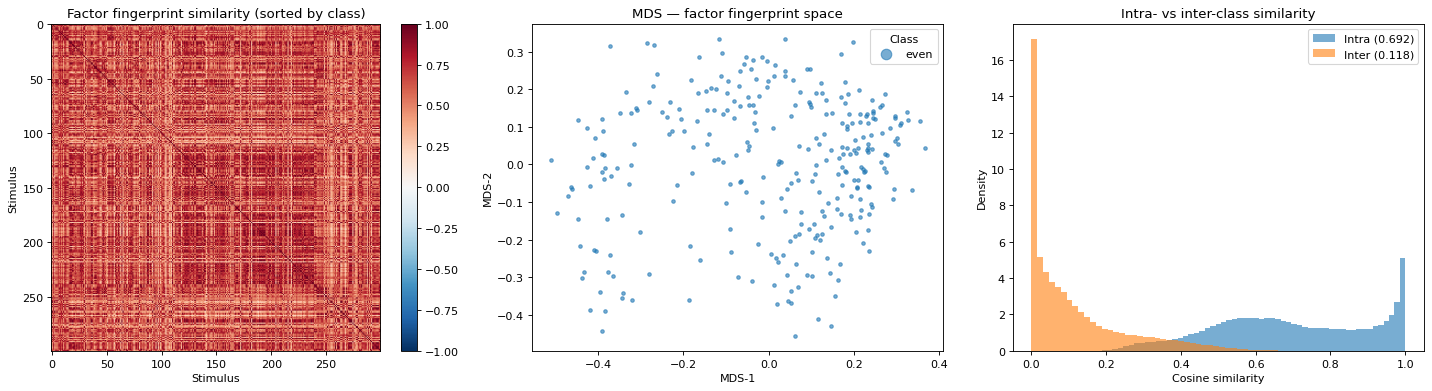

In [14]:
F = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))
print(f'Fingerprint matrix: {F.shape}')

MAX_VIZ = 300
rng = np.random.default_rng(42)
viz_idx = np.argsort(all_targets)[:MAX_VIZ] if n_samples > MAX_VIZ else np.argsort(all_targets)
S = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Similarity heatmap
im = axes[0].imshow(S, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0])
for cl in np.unique(targets_viz):
    for b in np.where(np.diff((targets_viz==cl).astype(int)))[0]:
        axes[0].axhline(b+0.5, color='k', lw=0.5)
        axes[0].axvline(b+0.5, color='k', lw=0.5)
axes[0].set(title='Factor fingerprint similarity (sorted by class)', xlabel='Stimulus', ylabel='Stimulus')

# MDS
coords = MDS(n_components=2, dissimilarity='precomputed',
             random_state=0, n_init=4).fit_transform(cosine_distances(F[viz_idx]))
cmap_tab = plt.get_cmap('tab10')
for cl in sorted(np.unique(targets_viz)):
    mask = targets_viz == cl
    axes[1].scatter(coords[mask,0], coords[mask,1], c=[cmap_tab(cl)], s=10, alpha=0.6,
                    label=CLASS_NAMES.get(cl, str(cl)))
axes[1].legend(markerscale=3, title='Class')
axes[1].set(title='MDS — factor fingerprint space', xlabel='MDS-1', ylabel='MDS-2')

# Intra/inter stats
S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci+1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets==cl2)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
axes[2].hist(intra_arr, bins=60, alpha=0.6, label=f'Intra ({intra_arr.mean():.3f})', density=True)
axes[2].hist(inter_arr, bins=60, alpha=0.6, label=f'Inter ({inter_arr.mean():.3f})', density=True)
axes[2].set(xlabel='Cosine similarity', ylabel='Density', title='Intra- vs inter-class similarity')
axes[2].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'nnls_fingerprints.pdf'), bbox_inches='tight')
plt.show()

### 4c — ID sanity check (training set)

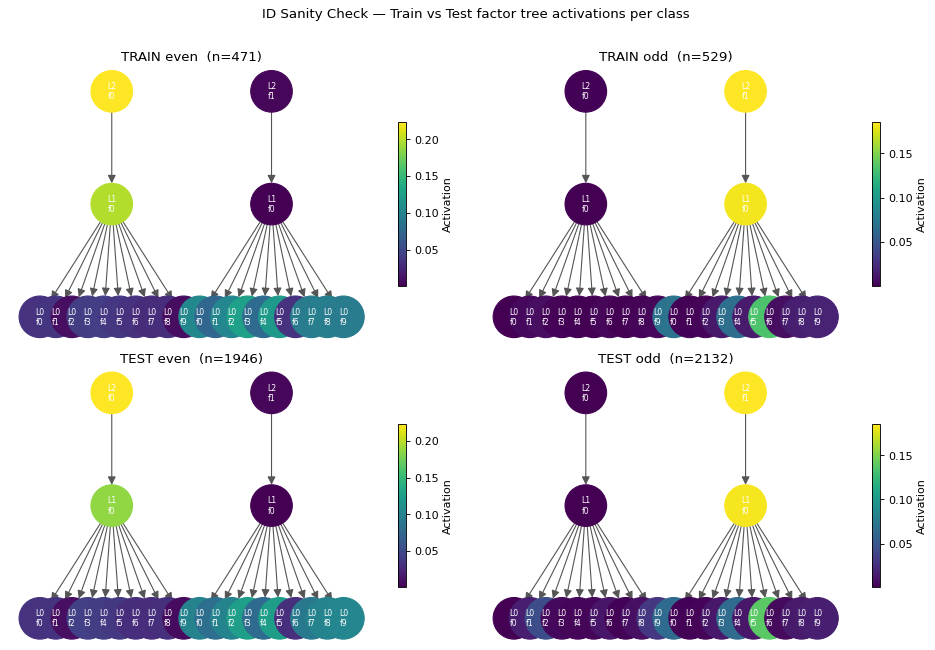

In [15]:
data_train = collect_layer_inputs(
    model, train_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=DEVICE,
)
idx_tr = np.random.default_rng(42).choice(len(data_train['images']), 1000, replace=False)
train_inputs  = [layer[idx_tr] for layer in data_train['layer_inputs']]
train_targets = data_train['targets'][idx_tr]

projected_train = project_stimuli_onto_tree(nnls_root, train_inputs)
factor_nodes_train = extract_factor_tree_nodes(projected_train)

# Side-by-side factor tree: train vs test per class
fig, axes = plt.subplots(2, N_CLASSES, figsize=(6*N_CLASSES, 8))
for col, cl in enumerate(classes):
    cl_name = CLASS_NAMES.get(cl, str(cl))
    tr_idx  = np.where(train_targets == cl)[0]
    acts_tr = compute_factor_activations(factor_nodes_train, tr_idx)
    plot_factor_tree(factor_nodes_train, acts_tr, ax=axes[0, col],
                     title=f'TRAIN {cl_name}  (n={len(tr_idx)})')
    te_idx  = np.where(all_targets == cl)[0]
    acts_te = compute_factor_activations(nnls_factor_nodes, te_idx)
    plot_factor_tree(nnls_factor_nodes, acts_te, ax=axes[1, col],
                     title=f'TEST {cl_name}  (n={len(te_idx)})')
plt.suptitle('ID Sanity Check — Train vs Test factor tree activations per class', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_tree_comparison.pdf'), bbox_inches='tight')
plt.show()

### 4d — Near-OOD: excluded MNIST digits (2,5,6,7,8,9)

OOD digits: [2, 5, 6, 7, 8, 9]


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_50183/3093739100.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ood_labels_all  = np.array(mnist_test_full.targets)


OOD samples: 5893


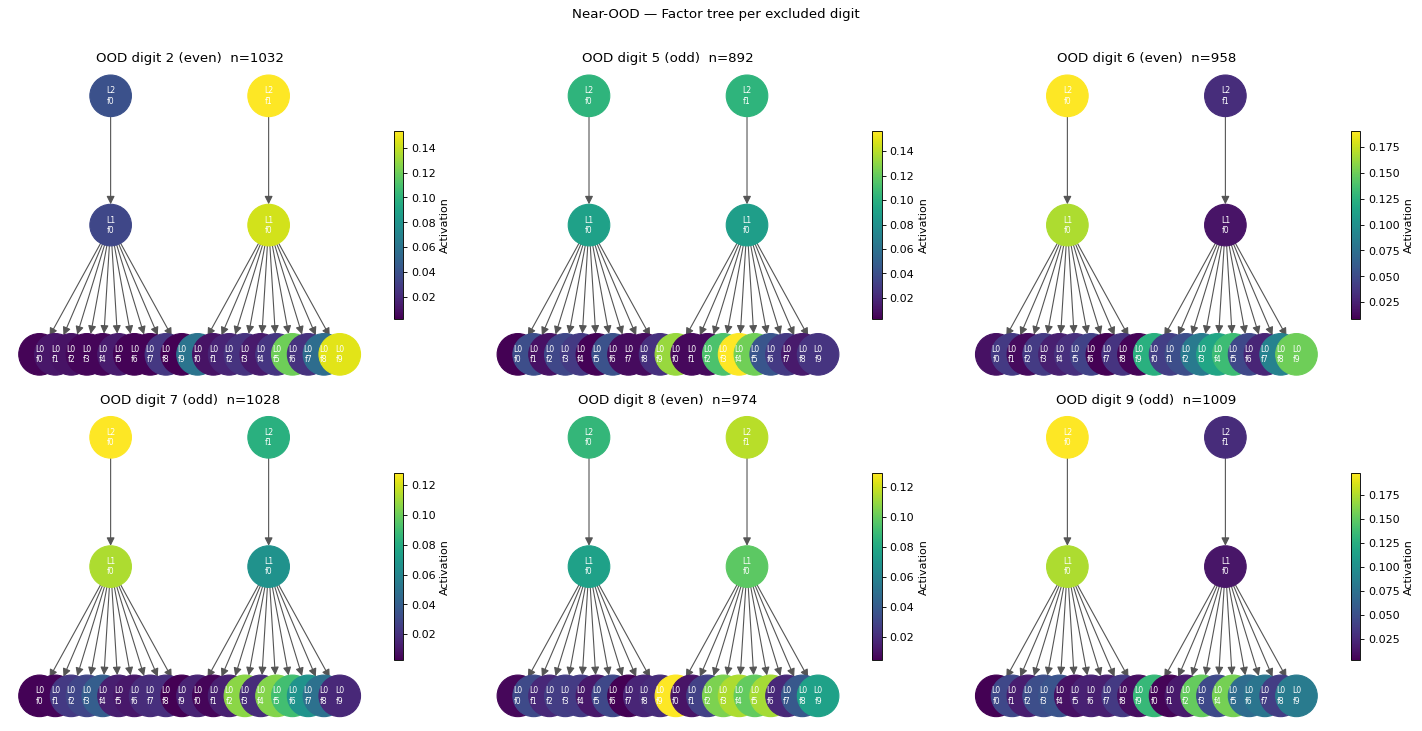

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


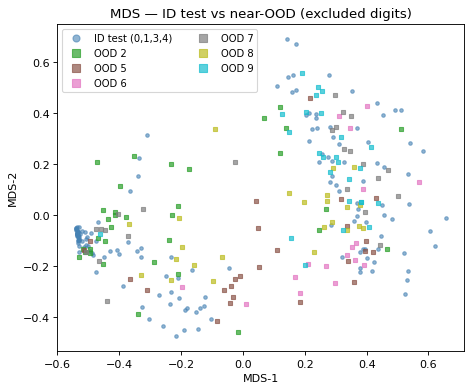

In [16]:
OOD_DIGITS = [d for d in range(10) if d not in digit_filter]
print(f'OOD digits: {OOD_DIGITS}')

mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
ood_labels_all  = np.array(mnist_test_full.targets)
ood_indices     = np.where(np.isin(ood_labels_all, OOD_DIGITS))[0]
ood_subset      = Subset(mnist_test_full, ood_indices)

data_ood = collect_layer_inputs_generic(
    model, ood_subset, label_transform=label_transform_even_odd,
    only_correct=False, device=DEVICE,
)
ood_images  = data_ood['images']
ood_digits  = data_ood['digits']
ood_targets = data_ood['targets']
ood_inputs  = data_ood['layer_inputs']
n_ood       = len(ood_images)
print(f'OOD samples: {n_ood}')

projected_ood = project_stimuli_onto_tree(nnls_root, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# Tree per OOD digit
unique_ood = sorted(np.unique(ood_digits))
ncols = min(3, len(unique_ood))
nrows = int(np.ceil(len(unique_ood) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4.5*nrows), squeeze=False)
for i, d in enumerate(unique_ood):
    ax  = axes[i // ncols][i % ncols]
    idx = np.where(ood_digits == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, idx)
    parity = 'even' if d % 2 == 0 else 'odd'
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'OOD digit {d} ({parity})  n={len(idx)}')
for j in range(len(unique_ood), nrows*ncols):
    axes[j//ncols][j%ncols].set_visible(False)
plt.suptitle('Near-OOD — Factor tree per excluded digit', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_tree_per_digit.pdf'), bbox_inches='tight')
plt.show()

# MDS: ID test vs near-OOD
N_EACH = 150
rng_m  = np.random.default_rng(7)
id_sub  = rng_m.choice(n_samples, min(N_EACH, n_samples), replace=False)
ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)
F_id    = extract_fingerprint_matrix(nnls_root, id_sub)
F_ood_s = extract_fingerprint_matrix(projected_ood, ood_sub)
coords  = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(
    cosine_distances(np.concatenate([F_id, F_ood_s])))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(coords[:len(id_sub), 0], coords[:len(id_sub), 1],
           c='steelblue', s=10, alpha=0.6, label='ID test (0,1,3,4)')
joint_digits_ood = ood_digits[ood_sub]
cmap_tab = plt.get_cmap('tab10')
for d in sorted(np.unique(joint_digits_ood)):
    mask = joint_digits_ood == d
    ax.scatter(coords[len(id_sub)+np.where(mask)[0], 0],
               coords[len(id_sub)+np.where(mask)[0], 1],
               c=[cmap_tab(d%10)], marker='s', s=12, alpha=0.7, label=f'OOD {d}')
ax.legend(markerscale=2, ncol=2, fontsize=9)
ax.set(title='MDS — ID test vs near-OOD (excluded digits)', xlabel='MDS-1', ylabel='MDS-2')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_mds.pdf'), bbox_inches='tight')
plt.show()

### 4e — Far OOD: synthetic images

gaussian_noise        model acc=0.000
uniform_gray          model acc=0.000
checkerboard          model acc=0.000
inverted_test         model acc=0.000


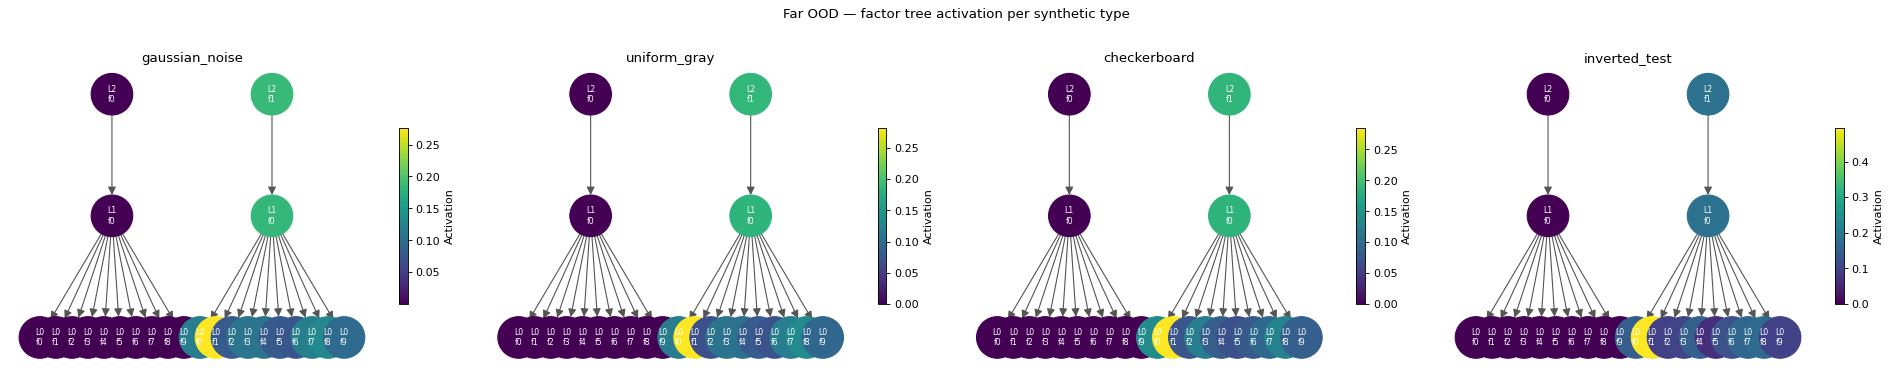

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


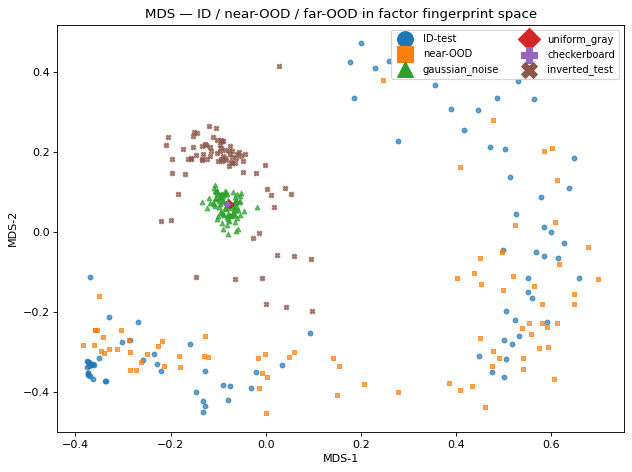

In [17]:
rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR_OOD], 0, 1).astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs),
                       torch.zeros(len(imgs), dtype=torch.long))
    d = collect_layer_inputs_generic(
        model, ds, label_transform=label_transform_even_odd,
        only_correct=False, device=DEVICE,
    )
    d['projected_root'] = project_stimuli_onto_tree(nnls_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  model acc={( d["preds"]==d["targets"]).mean():.3f}')

# Factor tree per type
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6*n_types, 4.5), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, far_ood_data.items()):
    acts = compute_factor_activations(d['factor_nodes'], np.arange(len(d['images'])))
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activation per synthetic type', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.pdf'), bbox_inches='tight')
plt.show()

# MDS: ID / near-OOD / far-OOD
N_MDS = 80
rng_m2 = np.random.default_rng(5)
F_parts, mds_labels, mds_markers = [], [], []

id_s2 = rng_m2.choice(n_samples, min(N_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(nnls_root, id_s2))
mds_labels  += ['ID-test'] * len(id_s2)
mds_markers += ['o'] * len(id_s2)

ood_s2 = rng_m2.choice(n_ood, min(N_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_s2))
mds_labels  += ['near-OOD'] * len(ood_s2)
mds_markers += ['s'] * len(ood_s2)

for (name, d), mkr in zip(far_ood_data.items(), ['^','D','P','X']):
    n  = min(N_MDS, len(d['images']))
    ss = rng_m2.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], ss))
    mds_labels  += [name] * n
    mds_markers += [mkr] * n

F_joint    = np.concatenate(F_parts)
coords_all = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))

unique_labels = list(dict.fromkeys(mds_labels))
cmap_tab2 = plt.get_cmap('tab10')
lc = {l: cmap_tab2(i%10) for i, l in enumerate(unique_labels)}
lm = dict(zip(mds_labels, mds_markers))

fig, ax = plt.subplots(figsize=(8, 6))
for i, lbl in enumerate(mds_labels):
    ax.scatter(coords_all[i, 0], coords_all[i, 1], c=[lc[lbl]], marker=lm[lbl], s=18, alpha=0.7)
for lbl in unique_labels:
    ax.scatter([], [], c=[lc[lbl]], marker=lm[lbl], s=50, label=lbl)
ax.legend(markerscale=2, ncol=2, fontsize=9)
ax.set(title='MDS — ID / near-OOD / far-OOD in factor fingerprint space',
       xlabel='MDS-1', ylabel='MDS-2')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'all_ood_mds.pdf'), bbox_inches='tight')
plt.show()